#### **How can we generate sequence data?**

The universal way to generate sequence data is to train a network to predict the next token or next few tokens in a sequence using the previous tokens as input.

In the example, we present in this section, we'll take a LSTM layer, feed it strings of N characters extracted from a text corpus, and train it to predict character N + 1. The output of the model will be a softmax over all possible characters: a probability distribution for the next character.

#### **The importance of the sampling strategy**

When generating text, the way you choose the next character is crucially important. A naive approach is `greedy sampling`, consisting of always choosing the moslt likely next character. But such an approach results in repetitive, predictable strings that don't look like coherent language. A more interesting approach makes slightly more surprising choices: it introduces randomness in the sampling process, by sampling from the probability distribution for the next character. This is called stochastic sampling.

In order to control the amount of stochasticity in the sampling process, we'll introduce a parameter called the softmax temperature that characterizes the entropy of the probability distribution used for sampling. Let's visualize it!!!

In [1]:
### Reweighting a probability distribution to a different temperature

import numpy as np

def reweight_distribution(original_distribution, temperature=0.5):
  # Add a small epsilon to avoid log(0) if original_distribution contains zeros
  # and clip to prevent extremely small numbers after adding epsilon leading to -inf
  original_distribution = np.clip(original_distribution, 1e-10, 1.0)

  # Convert probabilities to unnormalized log-probabilities (logits)
  logits = np.log(original_distribution)

  # Apply temperature scaling to the logits
  # A lower temperature makes the distribution sharper (more peaked)
  # A higher temperature makes it flatter (more uniform)
  scaled_logits = logits / temperature

  # Apply softmax to get the new probability distribution
  reweighted_distribution = np.exp(scaled_logits)
  return reweighted_distribution / np.sum(reweighted_distribution)

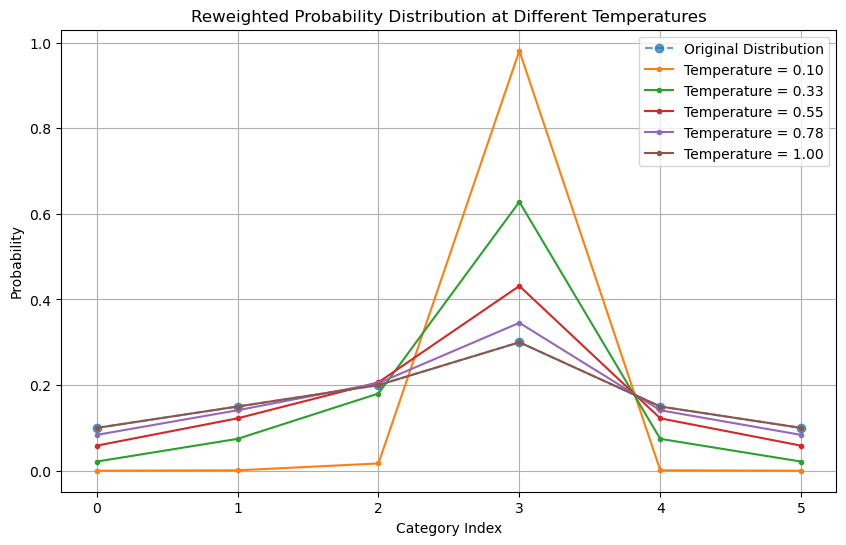

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Define an example original probability distribution
# This distribution should have positive values to avoid issues with np.log(0)
original_distribution = np.array([0.1, 0.15, 0.2, 0.3, 0.15, 0.1])
# Normalize the distribution to ensure it sums to 1
original_distribution = original_distribution / np.sum(original_distribution)

# Define the range of temperatures to plot
temperatures = np.linspace(0.1, 1.0, 5) # Plot for 5 different temperatures between 0.1 and 1.0

plt.figure(figsize=(10, 6))
indices = np.arange(len(original_distribution))

# Plot the original distribution
plt.plot(indices, original_distribution, label='Original Distribution', linestyle='--', marker='o', alpha=0.7)

# Plot reweighted distributions for each temperature
for temp in temperatures:
  reweighted_dist = reweight_distribution(original_distribution, temperature=temp)
  plt.plot(indices, reweighted_dist, label=f'Temperature = {temp:.2f}', marker='.')

plt.xlabel('Category Index')
plt.ylabel('Probability')
plt.title('Reweighted Probability Distribution at Different Temperatures')
plt.legend()
plt.grid(True)
plt.show()

Higher temperature result in sampling distributions of higher entropy that will generate more  surprising and unstructured generated data, whereas lower temperature will result in less randomness and much more predictable generated data.

#### **Implementing character-level LSTM text generation**

The first thing we need is a lot of text data that we can use to learn a language model. In thi example, we'll use some of the writings of Nietzsche. The language model will learn the Nietsche's writing style and the topics of choice.

In [3]:
### Downloading and parsing the intial text file
import keras
import numpy as np

path = keras.utils.get_file(
    'nietzsche.txt',
    origin = 'https://s3.amazonaws.com/text-datasets/nietzsche.txt'
)

text = open(path).read().lower()

print('corpus length:', len(text))

2026-06-29 18:54:40.533072: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-06-29 18:54:40.533091: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


600901/600901 [==============================] - 0s 1us/step
corpus length: 600893


Next, we'll extract partially overlapping sequences of length `maxlen`, one-hot encode them, and pack them in a 3D numpy array x of shape `(sequences, maxlen, unique_characters)`. Simultaneously we'll prepare an array y containing the corresponding targets: the one-hot-encoded characters that come after extracted sequence.

In [4]:
### Vectorizing sequences of characters
maxlen = 60 # we'll extract a sequence of 60 characters
step = 3 # we'll sample a new sequence every three characters
sentences = [] # hold the extracted sequences
next_chars = [] # holds the targets

for i in range(0, len(text) - maxlen, step):
  sentences.append(text[i: i + maxlen])
  next_chars.append(text[i + maxlen])

print('number of sequences:', len(sentences))

chars = sorted(list(set(text))) # list the unique characters in the corpus
print('Unique characters:', len(chars))
char_indices = dict((char, char.index(char)) for char in chars) # dictionary that maps unique characters to their index in the list

print('Vectorization...')
### One-hot encodes the characters into binary arrays
x = np.zeros((len(sentences), maxlen, len(chars)), dtype=np.bool)
y = np.zeros((len(sentences), len(chars)), dtype = np.bool)
for i, sentence in enumerate(sentences):
  for t, char in enumerate(sentence):
    x[i,t, char_indices[char]] = 1
  y[i, char_indices[next_chars[i]]] = 1

number of sequences: 200278
Unique characters: 57
Vectorization...


/tmp/ipykernel_59813/482350383.py:19: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  x = np.zeros((len(sentences), maxlen, len(chars)), dtype=np.bool)
/tmp/ipykernel_59813/482350383.py:20: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  y = np.zeros((len(sentences), len(chars)), dtype = np.bool)


### **Building the network**

This network is a single LSTM layer followed by a Dense classifier and softmax over all possible characters.

In [5]:
from keras import layers

model = keras.models.Sequential()
model.add(layers.LSTM(128, input_shape=(maxlen, len(chars))))
model.add(layers.Dense(len(chars), activation='softmax'))

### Model compilation configuration
optimizer = keras.optimizers.RMSprop(learning_rate=0.01)
model.compile(loss='categorical_crossentropy', optimizer = optimizer)

2026-06-29 18:54:47.928273: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-06-29 18:54:47.928378: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory
2026-06-29 18:54:47.928441: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublasLt.so.11'; dlerror: libcublasLt.so.11: cannot open shared object file: No such file or directory
2026-06-29 18:54:47.928500: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcufft.so.10'; dlerror: libcufft.so.10: cannot open shared object file: No such file or directory
2026-06-29 18:54:48.163387: W tensorflow/stream_executor/platform/default/dso_loader.cc:64

### **Training the language model and sampling from it**

Given a trained model and a seed text snippet, we can generate new text by doing the following repeatedly:



1.   Draw from the model a probability distribution for the next, character, given the generated text available so far.
2.   Reweight the distribution to a certain temperature.
3.   Sample the next character at random according to the reweighted distribution.
4.   Add the new character at the end of the available text.



In [6]:
### Function to sample the next character given the model's predictions

def sample(preds, temperature=1.0):
  preds = np.asarray(preds).astype('float64')
  preds = np.log(preds) / temperature
  exp_preds = np.exp(preds)
  preds = exp_preds / np.sum(exp_preds)
  probas = np.random.multinomial(1, preds, 1)
  return np.argmax(probas)

Finally, the following loop repeatedly trains and generates text. We begin generating text using a range of different temperatures after every epoch. This allows us to see how the generated text evolves as the model begins to converge, as well as the impact of temperature in the sampling strategy.

In [7]:
### Text-generation loop

import random
import sys

for epoch in range(1, 60):
  print('epoch', epoch)
  model.fit(x, y, batch_size = 128, epochs=1) # Fits the model for one iteration on the data
  # selects a text seed at random
  start_index = random.randint(0, len(text) - maxlen -1)
  generated_text = text[start_index: start_index + maxlen]
  print('--- Generating with seed: " ' + generated_text + '"')
  # Tries a range of different sampling temperatures
  for temperature in [0.2, 0.5, 1.0, 1.2]:
    print('------ temperature:', temperature)
    sys.stdout.write(generated_text)

    # Generates 400 characters starting from the seed text
    for i in range(400):
      # One-hot encodes the characters generated so far
      sampled = np.zeros((1, maxlen, len(chars)))
      for t, char in enumerate(generated_text):
        sampled[0, t, char_indices[char]] = 1
      # Samples the next character
      preds = model.predict(sampled, verbose=0)[0]
      next_index = sample(preds, temperature)
      next_char = chars[next_index]

      generated_text += next_char
      generated_text = generated_text[1:]

      sys.stdout.write(next_char)

epoch 1
1565/1565 [==============================] - 101s 63ms/step - loss: 0.0027
--- Generating with seed: " is only an instrument, we may say, he is a mirror--he is no
"
------ temperature: 0.2
is only an instrument, we may say, he is a mirror--he is no
















































































































































































































































































































































































































------ temperature: 0.5































































































































































































































































































































